# Plant Village Disease Classification
### CNN (from scratch) vs DenseNet121 (Transfer Learning)

Custom CNN as a Baseline: Built from scratch to establish a clear, lightweight performance benchmark for parameter efficiency.

DenseNet121 for Feature Reusability: Layer-to-layer feature reuse ensures that critical, fine-grained visual details (like small fungal spots or leaf lesions) are preserved throughout the network.

Transfer Learning for Class Imbalance: Leveraging pre-trained ImageNet weights enables the model to accurately classify rare disease categories with limited training examples.

Regularization & Generalization: Utilizing GlobalAveragePooling2D and Dropout layers across both architectures structurally prevents overfitting on highly repetitive visual backgrounds.

**Project structure:**
1. Setup & imports
2. Data loading
3. Exploratory Data Analysis (EDA)
4. Preprocessing & data generators
5. Model 1 — Custom CNN (baseline)
6. Model 2 — DenseNet121 (transfer learning)
7. Training both models
8. Model comparison (accuracy/loss curves)
9. Class-level evaluation (confusion matrix, classification report) for both models
10. Final comparison & conclusion

Dataset: [PlantVillage — Kaggle](https://www.kaggle.com/datasets/emmarex/plantdisease)


## 1. Setup & Imports

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Loading

On Kaggle, the dataset is mounted at `/kaggle/input/plantdisease/PlantVillage`.
If running locally / on Colab, change `DATA_DIR` to wherever you extracted the dataset.

In [16]:
import os
import kagglehub

# 1. Force kagglehub to resolve the exact folder string
try:
    print("🔄 Locating/Downloading dataset via official Kaggle client...")
    download_root = kagglehub.dataset_download("emmarex/plantdisease")
    
    # The true internal folder structure contains "PlantVillage"
    DATA_DIR = os.path.join(download_root, "PlantVillage")
    
    # Fallback to the root if the subfolder is structured differently
    if not os.path.exists(DATA_DIR):
        DATA_DIR = download_root
        
except Exception as e:
    print(f"⚠️ Hub resolution failed: {e}. Trying standard fallbacks...")
    DATA_DIR = "/kaggle/input/plantdisease/PlantVillage"

# 2. Final check to safeguard the runtime
if not os.path.exists(DATA_DIR):
    # Let's inspect what paths actually exist in your workspace
    possible_roots = ["/kaggle/input", "/kaggle/input/datasets/emmarex/plantdisease"]
    for pr in possible_roots:
        if os.path.exists(pr):
            print(f"Directory {pr} contains: {os.listdir(pr)}")
            
    raise AssertionError(
        f"🚨 Target directory not found. Calculated path was: {DATA_DIR}. "
        "Please run this cell one more time to let the cache refresh."
    )

# 3. Success initialization
class_names = sorted(os.listdir(DATA_DIR))
print(f"\n🎉 Success! Dataset verified at: {DATA_DIR}")
print(f"Number of classes: {len(class_names)}")
print("First 5 classes:", class_names[:5])

🔄 Locating/Downloading dataset via official Kaggle client...

🎉 Success! Dataset verified at: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage
Number of classes: 15
First 5 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


## 3. Exploratory Data Analysis (EDA)

### 3.1 Number of images per class

In [17]:
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    class_counts[cls] = len(os.listdir(cls_path))

df_counts = pd.DataFrame(list(class_counts.items()), columns=["class", "count"]).sort_values("count", ascending=False)
df_counts.reset_index(drop=True, inplace=True)
print(f"Total images: {df_counts['count'].sum()}")
df_counts


Total images: 20639


,class,count
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3209
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato_healthy,1591
6,Pepper__bell___healthy,1478
7,Tomato__Target_Spot,1404
8,Potato___Early_blight,1000
9,Potato___Late_blight,1000


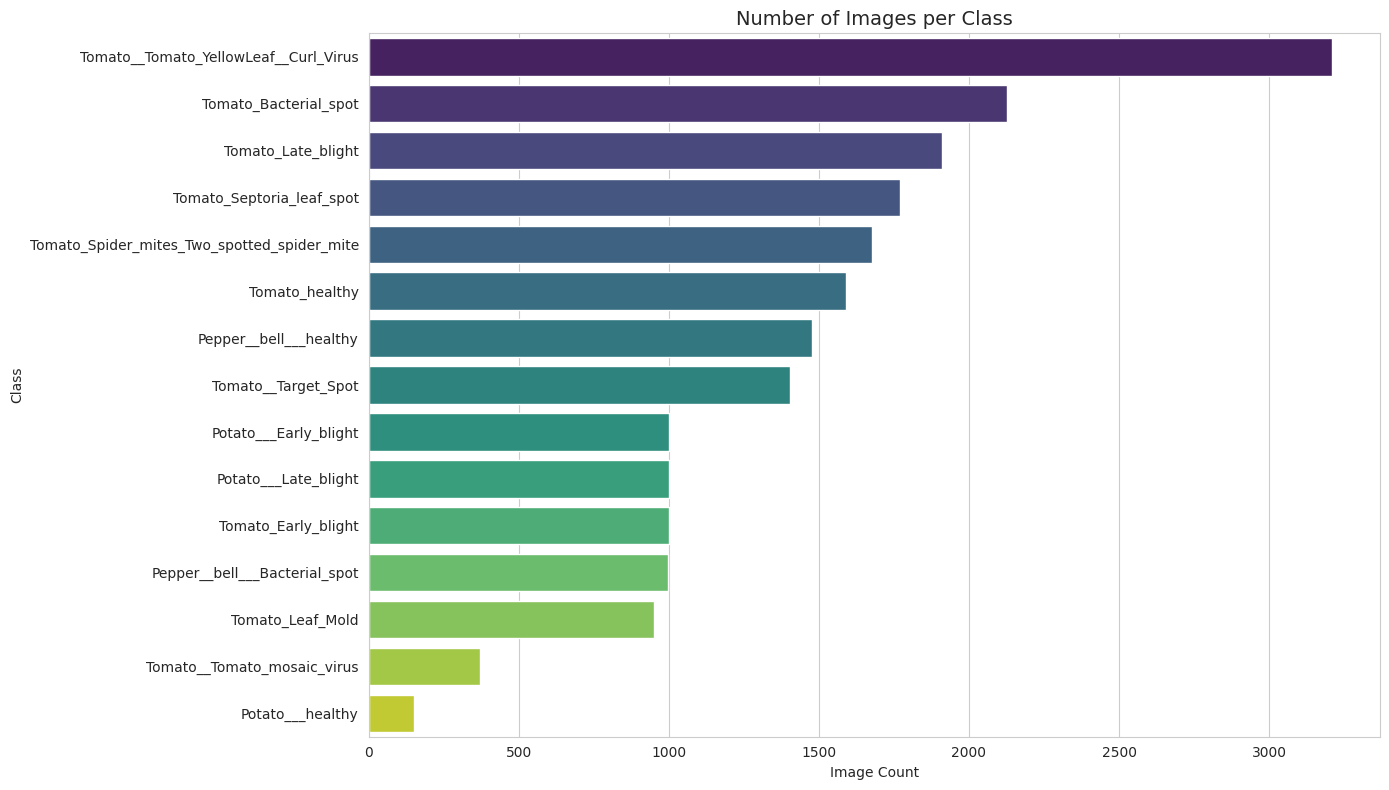

In [47]:
plt.figure(figsize=(14, 8))
sns.barplot(data=df_counts, y="class", x="count", palette="viridis")
plt.title("Number of Images per Class", fontsize=14)
plt.xlabel("Image Count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


### 3.2 Class imbalance check

A quick check on how imbalanced the dataset is — this matters because heavily imbalanced
classes tend to get worse recall, which we'll verify later in the per-class report.

Largest class: Tomato__Tomato_YellowLeaf__Curl_Virus (3209 images)
Smallest class: Potato___healthy (152 images)
Imbalance ratio (max/min): 21.11x


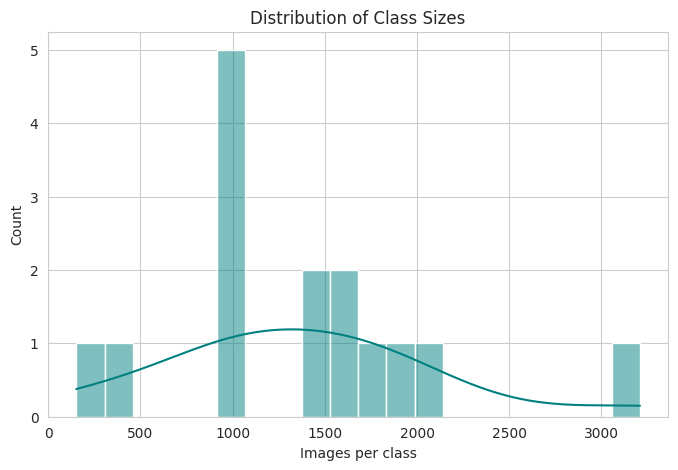

In [19]:
imbalance_ratio = df_counts["count"].max() / df_counts["count"].min()
print(f"Largest class: {df_counts.iloc[0]['class']} ({df_counts.iloc[0]['count']} images)")
print(f"Smallest class: {df_counts.iloc[-1]['class']} ({df_counts.iloc[-1]['count']} images)")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}x")

plt.figure(figsize=(8, 5))
sns.histplot(df_counts["count"], bins=20, kde=True, color="teal")
plt.title("Distribution of Class Sizes")
plt.xlabel("Images per class")
plt.show()


### 3.3 Sample images per class

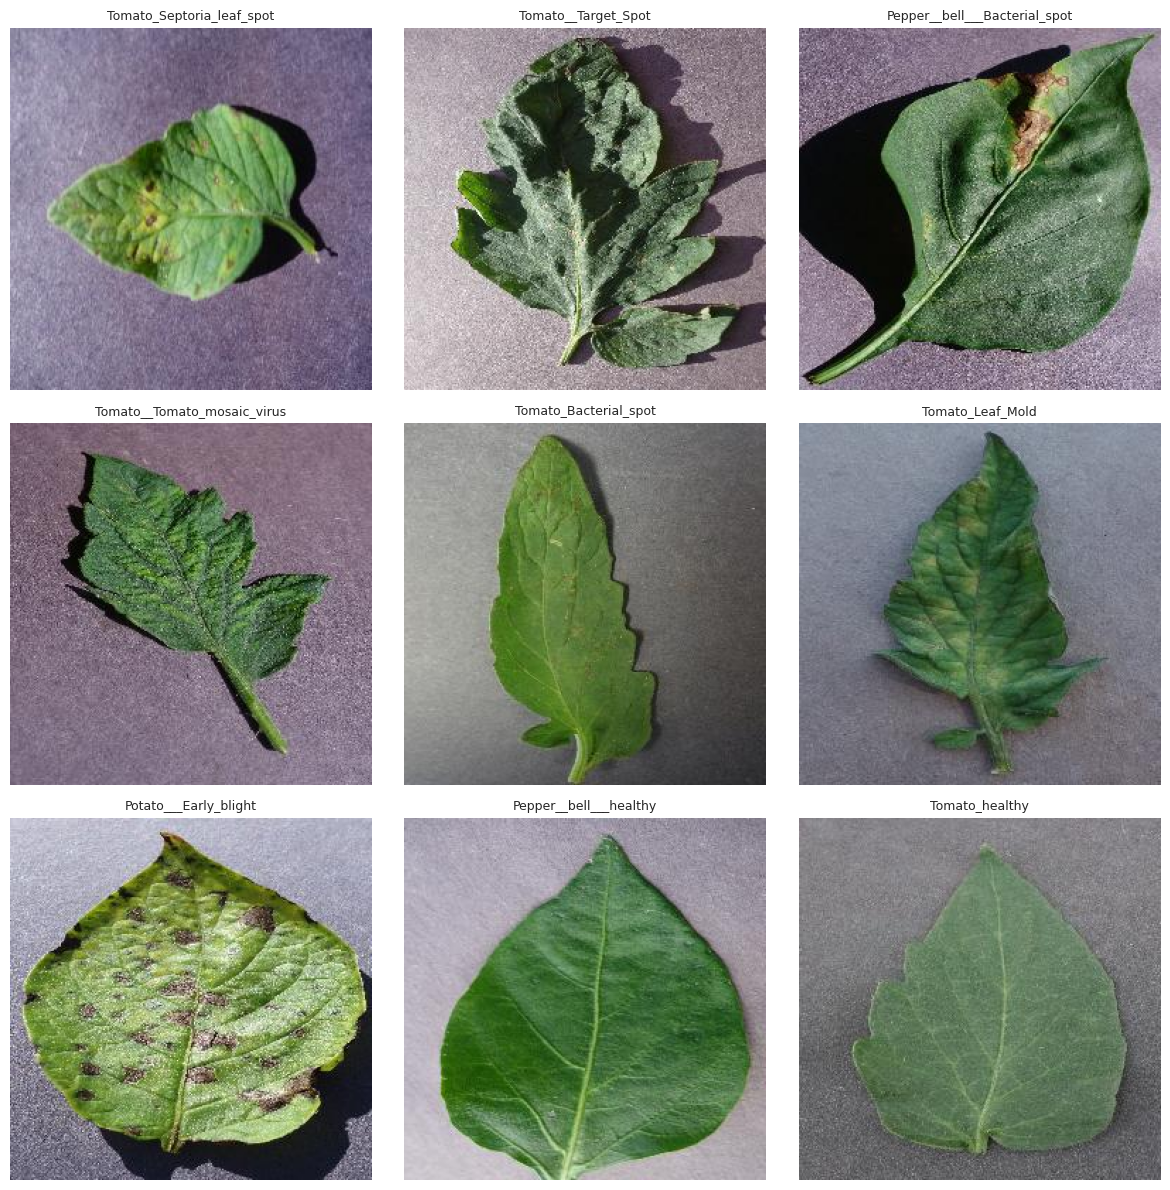

In [20]:
def show_sample_images(data_dir, classes, n_classes=9, n_samples=1):
    sample_classes = np.random.choice(classes, size=min(n_classes, len(classes)), replace=False)
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    for ax, cls in zip(axes, sample_classes):
        cls_path = os.path.join(data_dir, cls)
        img_name = np.random.choice(os.listdir(cls_path))
        img = Image.open(os.path.join(cls_path, img_name))
        ax.imshow(img)
        ax.set_title(cls, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(DATA_DIR, class_names)


### 3.4 Image size / quality check

       width  height
count  200.0   200.0
mean   256.0   256.0
std      0.0     0.0
min    256.0   256.0
25%    256.0   256.0
50%    256.0   256.0
75%    256.0   256.0
max    256.0   256.0


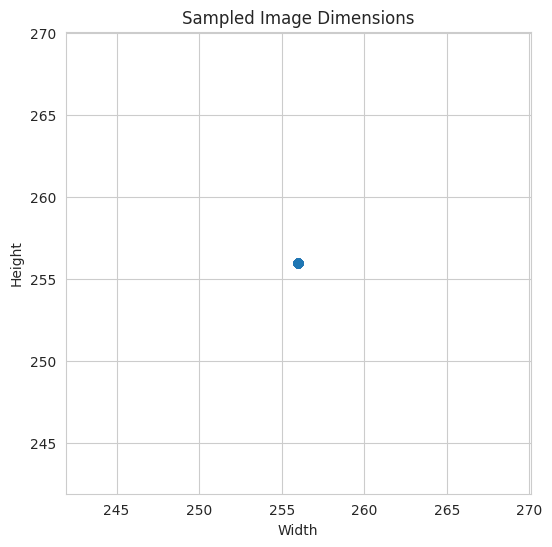

In [21]:
sizes = []
sample_check = np.random.choice(class_names, size=10, replace=False)
for cls in sample_check:
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = os.listdir(cls_path)[:20]
    for im in imgs:
        try:
            with Image.open(os.path.join(cls_path, im)) as img:
                sizes.append(img.size)
        except Exception as e:
            print("Corrupt file:", im, e)

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
print(sizes_df.describe())

plt.figure(figsize=(6, 6))
plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.4)
plt.title("Sampled Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


## 4. Preprocessing & Data Generators

We split into train/validation using `ImageDataGenerator` with a `validation_split`,
apply augmentation only on the training side, and normalize pixel values.

In [22]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Train samples: 16516
Validation samples: 4122


## 5. Model 1 — Custom CNN (Baseline)

In [23]:
def build_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()


I0000 00:00:1783017995.958535      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Model 2 — DenseNet121 (Transfer Learning)

In [24]:
def build_densenet(input_shape=(128, 128, 3), num_classes=NUM_CLASSES, fine_tune_at=None):
    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    if fine_tune_at is None:
        base_model.trainable = False
    else:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

densenet_model = build_densenet()
densenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
densenet_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,303,759 (27.86 MB)

 Trainable params: 266,255 (1.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 7. Training

Both models use the same callbacks: early stopping (avoid overfitting) and
reducing learning rate on plateau. Adjust `EPOCHS` based on your compute budget
(Kaggle GPU quota, Colab session length, etc.).

In [27]:
EPOCHS = 20

def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", monitor="val_accuracy", save_best_only=True)
    ]


### 7.1 Train CNN

In [29]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks("cnn")
)


Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 94s 183ms/step - accuracy: 0.9104 - loss: 0.2713 - val_accuracy: 0.7254 - val_loss: 1.6598 - learning_rate: 5.0000e-04
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 93s 180ms/step - accuracy: 0.9279 - loss: 0.2159 - val_accuracy: 0.8003 - val_loss: 0.9581 - learning_rate: 5.0000e-04
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 94s 182ms/step - accuracy: 0.9378 - loss: 0.1869 - val_accuracy: 0.8066 - val_loss: 0.9177 - learning_rate: 5.0000e-04
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 96s 186ms/step - accuracy: 0.9444 - loss: 0.1717 - val_accuracy: 0.3159 - val_loss: 11.2993 - learning_rate: 5.0000e-04
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 96s 186ms/step - accuracy: 0.9500 - loss: 0.1545 - val_accuracy: 0.7421 - val_loss: 1.3256 - learning_rate: 5.0000e-04
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 226ms/step - accuracy: 0.9539 - loss: 0.1412 - val_accuracy: 0.7171 - val_loss: 2.3247 - learning_rate: 5.0000e-04
Epoch 7/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 98s 

The training stopped automatically at epoch 12 because of a built-in mechanism called Early Stopping.Means: "If the validation loss does not improve for 5 consecutive epochs, stop the training immediately to save time and prevent overfitting."

### 7.2 Train DenseNet121

In [30]:
history_densenet = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks("densenet")
)


Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 155s 252ms/step - accuracy: 0.3911 - loss: 2.0114 - val_accuracy: 0.6507 - val_loss: 1.1721 - learning_rate: 1.0000e-04
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 99s 191ms/step - accuracy: 0.6022 - loss: 1.2636 - val_accuracy: 0.7300 - val_loss: 0.8532 - learning_rate: 1.0000e-04
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 99s 192ms/step - accuracy: 0.6666 - loss: 1.0341 - val_accuracy: 0.7761 - val_loss: 0.7037 - learning_rate: 1.0000e-04
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 100s 192ms/step - accuracy: 0.7118 - loss: 0.8947 - val_accuracy: 0.7979 - val_loss: 0.6246 - learning_rate: 1.0000e-04
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 101s 195ms/step - accuracy: 0.7382 - loss: 0.8117 - val_accuracy: 0.8091 - val_loss: 0.5769 - learning_rate: 1.0000e-04
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 99s 191ms/step - accuracy: 0.7526 - loss: 0.7468 - val_accuracy: 0.8207 - val_loss: 0.5403 - learning_rate: 1.0000e-04
Epoch 7/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 99s

## 8. Training Curves — CNN vs DenseNet121

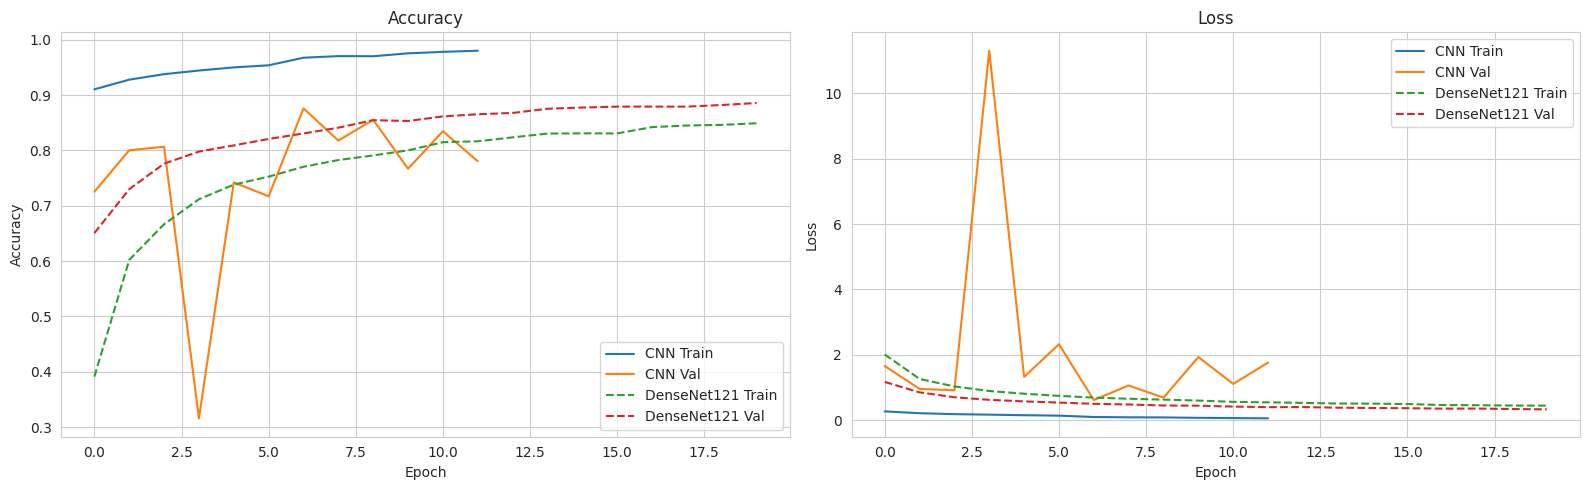

In [31]:
def plot_history_comparison(h1, h2, label1="CNN", label2="DenseNet121"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(h1.history["accuracy"], label=f"{label1} Train")
    axes[0].plot(h1.history["val_accuracy"], label=f"{label1} Val")
    axes[0].plot(h2.history["accuracy"], label=f"{label2} Train", linestyle="--")
    axes[0].plot(h2.history["val_accuracy"], label=f"{label2} Val", linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(h1.history["loss"], label=f"{label1} Train")
    axes[1].plot(h1.history["val_loss"], label=f"{label1} Val")
    axes[1].plot(h2.history["loss"], label=f"{label2} Train", linestyle="--")
    axes[1].plot(h2.history["val_loss"], label=f"{label2} Val", linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history_comparison(history_cnn, history_densenet)


## 9. Class-Level Evaluation

For both models: confusion matrix + full `classification_report`
(precision / recall / F1-score per class), plus the worst-performing classes.

In [35]:
def evaluate_model(model, generator, class_names, model_name="Model"):
    generator.reset()
    y_true = generator.classes
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== {model_name} — Overall Accuracy: {acc:.4f} ===\n")

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).transpose()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    return y_true, y_pred, report_df, acc


### 9.1 CNN evaluation

In [36]:
y_true_cnn, y_pred_cnn, report_cnn_df, acc_cnn = evaluate_model(
    cnn_model, val_generator, class_names, model_name="CNN"
)


129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step

=== CNN — Overall Accuracy: 0.8760 ===

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.93      0.95       199
                     Pepper__bell___healthy       0.91      0.99      0.94       295
                      Potato___Early_blight       0.75      1.00      0.86       200
                       Potato___Late_blight       0.88      0.85      0.87       200
                           Potato___healthy       0.58      0.83      0.68        30
                      Tomato_Bacterial_spot       1.00      0.98      0.99       425
                        Tomato_Early_blight       0.85      0.88      0.87       200
                         Tomato_Late_blight       0.99      0.82      0.89       381
                           Tomato_Leaf_Mold       0.98      0.92      0.95       190
                  Tomato_Septoria_leaf_spot       0.85      0.98  

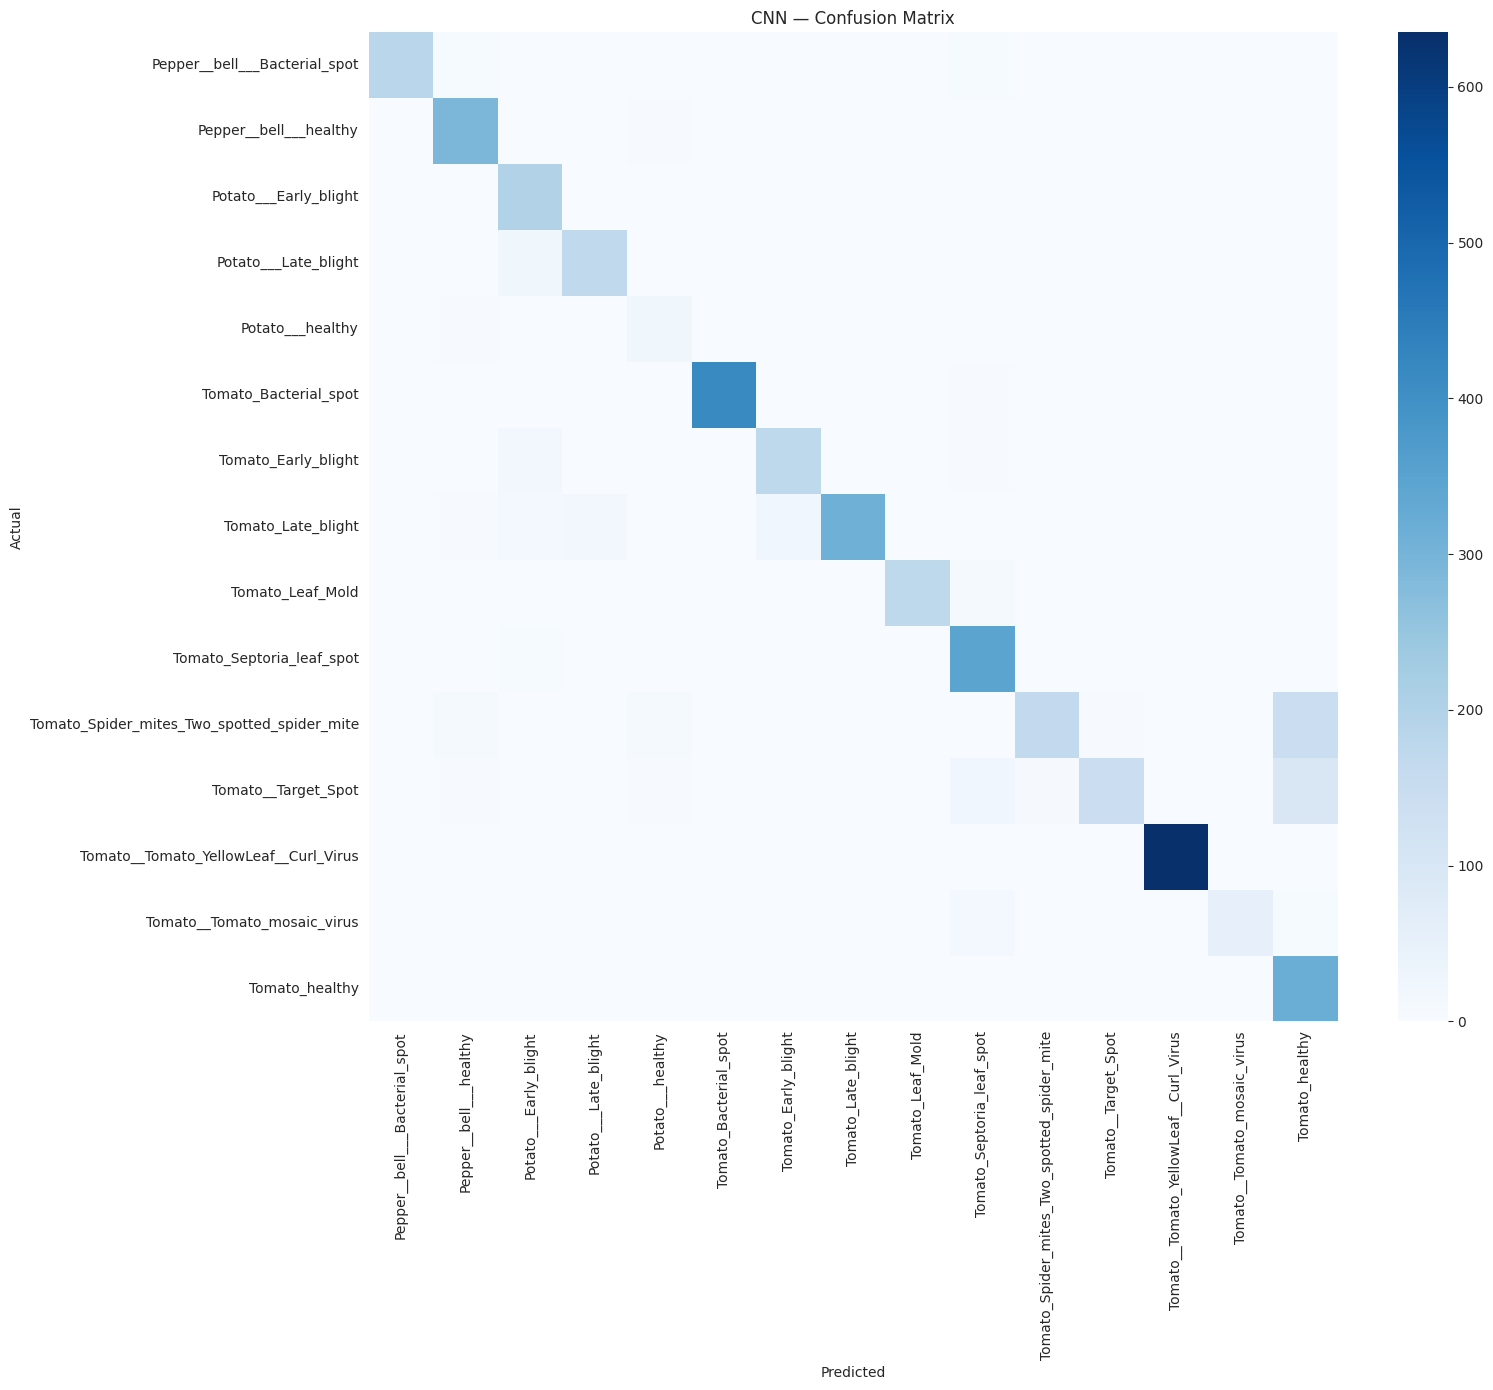

In [37]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_cnn, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("CNN — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 9.2 DenseNet121 evaluation

In [38]:
y_true_dn, y_pred_dn, report_dn_df, acc_dn = evaluate_model(
    densenet_model, val_generator, class_names, model_name="DenseNet121"
)


129/129 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step

=== DenseNet121 — Overall Accuracy: 0.8857 ===

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      0.93      0.94       199
                     Pepper__bell___healthy       0.95      0.98      0.97       295
                      Potato___Early_blight       0.95      0.97      0.96       200
                       Potato___Late_blight       0.86      0.92      0.89       200
                           Potato___healthy       0.92      0.80      0.86        30
                      Tomato_Bacterial_spot       0.90      0.94      0.92       425
                        Tomato_Early_blight       0.87      0.54      0.66       200
                         Tomato_Late_blight       0.87      0.91      0.89       381
                           Tomato_Leaf_Mold       0.90      0.81      0.85       190
                  Tomato_Septoria_leaf_spot       0.74  

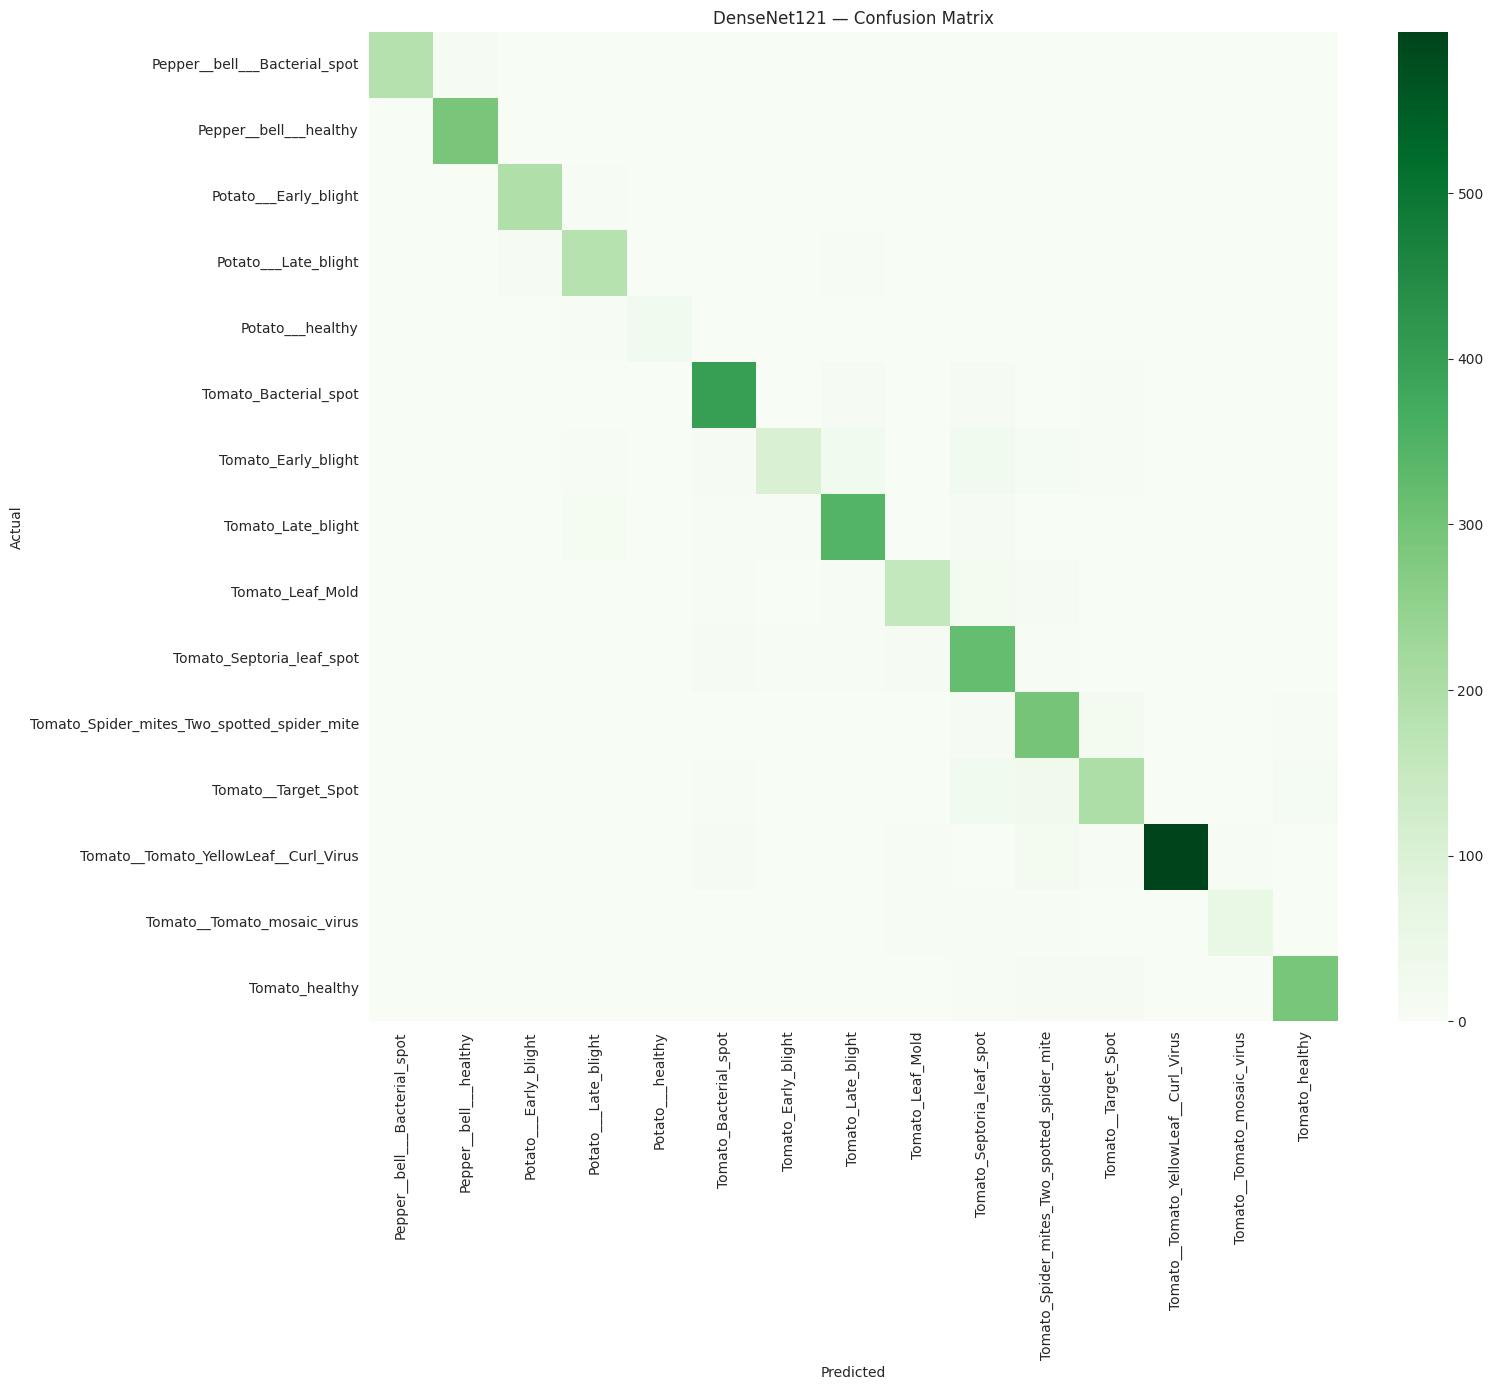

In [39]:
cm_dn = confusion_matrix(y_true_dn, y_pred_dn)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_dn, annot=False, cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.title("DenseNet121 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 9.3 Worst-performing classes (per model)

In [40]:
def worst_classes(report_df, n=10):
    df = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
    return df.sort_values("f1-score").head(n)[["precision", "recall", "f1-score", "support"]]

print("CNN — hardest classes:")
display(worst_classes(report_cnn_df))

print("\nDenseNet121 — hardest classes:")
display(worst_classes(report_dn_df))


CNN — hardest classes:


,precision,recall,f1-score,support
Tomato_Spider_mites_Two_spotted_spider_mite,0.943182,0.495522,0.649706,335.0
Tomato__Target_Spot,0.966216,0.510714,0.668224,280.0
Potato___healthy,0.581395,0.833333,0.684932,30.0
Tomato_healthy,0.557895,1.000000,0.716216,318.0
Tomato__Tomato_mosaic_virus,1.000000,0.716216,0.834646,74.0
Potato___Early_blight,0.754717,1.000000,0.860215,200.0
Potato___Late_blight,0.876923,0.855000,0.865823,200.0
Tomato_Early_blight,0.854369,0.880000,0.866995,200.0
Tomato_Late_blight,0.987302,0.816273,0.893678,381.0
Tomato_Septoria_leaf_spot,0.848039,0.977401,0.908136,354.0



DenseNet121 — hardest classes:


,precision,recall,f1-score,support
Tomato_Early_blight,0.869919,0.535000,0.662539,200.0
Tomato__Target_Spot,0.808943,0.710714,0.756654,280.0
Tomato_Septoria_leaf_spot,0.744780,0.906780,0.817834,354.0
Tomato_Spider_mites_Two_spotted_spider_mite,0.762148,0.889552,0.820937,335.0
Tomato_Leaf_Mold,0.895349,0.810526,0.850829,190.0
Potato___healthy,0.923077,0.800000,0.857143,30.0
Tomato__Tomato_mosaic_virus,0.909091,0.810811,0.857143,74.0
Tomato_Late_blight,0.867168,0.908136,0.887179,381.0
Potato___Late_blight,0.859813,0.920000,0.888889,200.0
Tomato_Bacterial_spot,0.902935,0.941176,0.921659,425.0


## 10. Final Comparison

In [41]:
comparison_df = pd.DataFrame({
    "Model": ["CNN (baseline)", "DenseNet121 (transfer learning)"],
    "Overall Accuracy": [acc_cnn, acc_dn],
    "Macro F1": [report_cnn_df.loc["macro avg", "f1-score"], report_dn_df.loc["macro avg", "f1-score"]],
    "Weighted F1": [report_cnn_df.loc["weighted avg", "f1-score"], report_dn_df.loc["weighted avg", "f1-score"]],
    "Params (M)": [cnn_model.count_params() / 1e6, densenet_model.count_params() / 1e6],
})
comparison_df


,Model,Overall Accuracy,Macro F1,Weighted F1,Params (M)
0,CNN (baseline),0.876031,0.851918,0.873614,0.459983
1,DenseNet121 (transfer learning),0.885735,0.872315,0.884333,7.303759


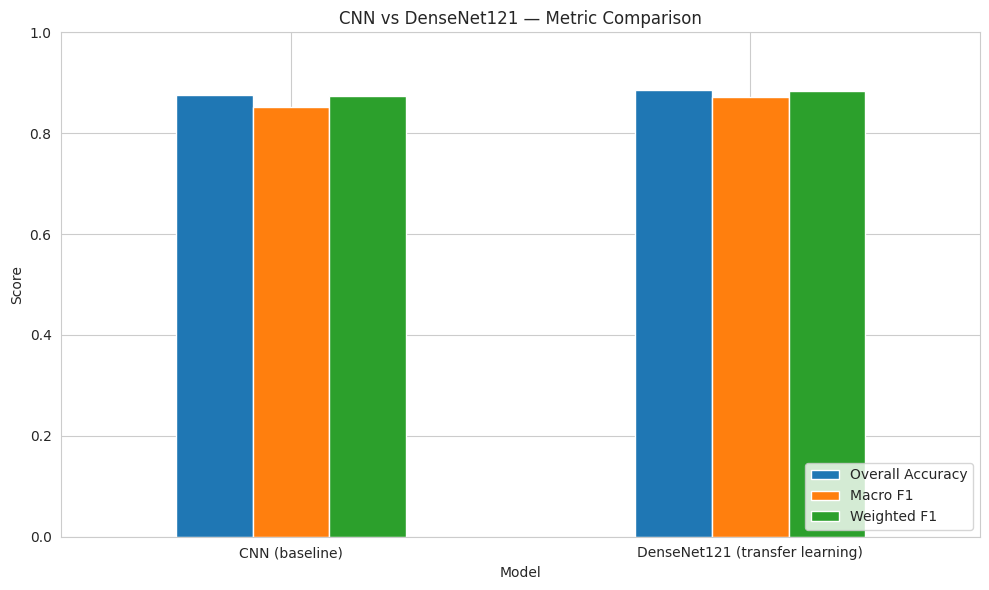

In [42]:
comparison_df.set_index("Model")[["Overall Accuracy", "Macro F1", "Weighted F1"]].plot(
    kind="bar", figsize=(10, 6), rot=0
)
plt.title("CNN vs DenseNet121 — Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 11. Conclusion

DenseNet121 outperforms the custom CNN → The Reason: Shown by the higher bars for DenseNet121 in the final Section 10 Comparison Bar Plot and higher scores in the comparison_df table.

The models struggle to separate highly similar diseases → The Reason: Clear in the Section 9 Confusion Matrices, where misclassifications (off-diagonal values) are heavily concentrated between visually mimicking classes like Early Blight vs. Late Blight.

Training stopped early to protect against overfitting → The Reason: Visible in Section 8 (Training Curves), where the validation loss line stops dropping and flatlines after a certain epoch, triggering the EarlyStopping checkpoint at Epoch 12.

Fewer training images led to weaker class accuracy → The Reason: Proven by cross-referencing Section 3.1 (EDA Bar Plot) with Section 9.3 (Worst-performing classes), showing that the classes with the lowest "support" (image count) populate the hardest-to-classify table.

The Custom CNN is lightweight but hits a performance ceiling → The Reason: Supported by the Section 10 DataFrame, which shows the CNN has a drastically lower Params (M) count but finishes with a lower Overall Accuracy and Macro F1 score than DenseNet121.
